# EEG Digit Classification

## Notebook 01 — Data Acquisition & Dataset Exploration

### Objective

The purpose of this notebook is to explore and validate the **MindBigData2023 MNIST-2B** dataset before building preprocessing and machine learning pipelines.

By the end of this notebook, we will:

- Load the dataset from Hugging Face
- Understand the dataset structure
- Validate the EEG data format
- Inspect labels and metadata
- Verify assumptions from the original paper
- Prepare for preprocessing in the next phase

In [2]:
## Imports

from datasets import load_dataset
from itertools import islice

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load Dataset

The MindBigData2023 MNIST-2B dataset is hosted on Hugging Face.

To avoid downloading the complete dataset (~27 GB) during exploration, we use **streaming mode**, which loads samples on demand instead of downloading the entire dataset.

In [3]:
## Load Dataset

ds = load_dataset(
    "DavidVivancos/MindBigData2023_MNIST-2B",
    streaming=True
)

In [4]:
ds

IterableDatasetDict({
    train: IterableDataset({
        features: Unknown,
        num_shards: 1
    })
    test: IterableDataset({
        features: Unknown,
        num_shards: 1
    })
})

## 2. Inspect One Sample

Before writing preprocessing code, we first need to understand what a single sample (trial) looks like.

In [5]:
## Inspect 1 Sample

train_iter = iter(ds["train"])
sample = next(train_iter)

In [6]:
print(f"Data Type: {type(sample)}")
print(f"Total columns: {len(sample)}")
print(f"Label: {sample["label"]}")

Data Type: <class 'dict'>
Total columns: 33559
Label: -1


In [7]:
# Display the first 20 column names

list(sample.keys())[:5]

['FP1_0', 'FP1_1', 'FP1_2', 'FP1_3', 'FP1_4']

In [11]:
# Display the last 20 column names

list(sample.keys())[-5:]

['label_imgpix_783', 'timestamp', 'sessionnum', 'blocknum', 'blockpos']

## 3. Identify Different Types of Columns

Each sample contains four categories of information:

- EEG recordings
- Label information
- MNIST image pixels
- Metadata

We will separate these programmatically to better understand the dataset structure.

In [12]:
# Separate different types of columns

keys = list(sample.keys())

eeg_columns = [
    key
    for key in keys
    if "_" in key and not key.startswith("label")
]

image_columns = [
    key
    for key in keys
    if key.startswith("label_imgpix")
]

label_columns = [
    key
    for key in keys
    if key.startswith("label")
]

metadata_columns = [
    "timestamp",
    "sessionnum",
    "blocknum",
    "blockpos"
]

print(f"Total columns      : {len(keys)}")
print(f"EEG columns        : {len(eeg_columns)}")
print(f"Image pixel columns: {len(image_columns)}")
print(f"Label columns      : {len(label_columns)}")
print(f"Metadata columns   : {len(metadata_columns)}")

Total columns      : 33559
EEG columns        : 32768
Image pixel columns: 784
Label columns      : 787
Metadata columns   : 4


In [13]:
print(label_columns[:10])

['label', 'label_source', 'label_pos', 'label_imgpix_0', 'label_imgpix_1', 'label_imgpix_2', 'label_imgpix_3', 'label_imgpix_4', 'label_imgpix_5', 'label_imgpix_6']


In [14]:
print(metadata_columns)

['timestamp', 'sessionnum', 'blocknum', 'blockpos']


## 4. Validate EEG Structure

The original MindBigData2023 paper describes recordings with **128 channels** and **256 samples per channel**.

The Hugging Face version appears to use a reduced representation.

Let's verify the actual structure programmatically.

In [15]:
# Extract unique channel names

channel_names = sorted(
    {
        column.rsplit("_", 1)[0]
        for column in eeg_columns
    }
)

print(f"Number of channels: {len(channel_names)}")
print(channel_names)

Number of channels: 128
['AF3', 'AF4', 'AF7', 'AF8', 'AFF1h', 'AFF2h', 'AFF5h', 'AFF6h', 'AFPz', 'AFp1', 'AFp2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'CCP1h', 'CCP2h', 'CCP3h', 'CCP4h', 'CCP5h', 'CCP6h', 'CP3', 'CP4', 'CP5', 'CP6', 'CPP1h', 'CPP2h', 'CPP3h', 'CPP4h', 'CPP5h', 'CPP6h', 'Cpz', 'Cz', 'F1', 'F10', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'FC1', 'FC2', 'FC3', 'FC4', 'FC5', 'FC6', 'FCC1h', 'FCC2h', 'FCC3h', 'FCC4h', 'FCC5h', 'FCC6h', 'FCz', 'FFC1h', 'FFC2h', 'FFC3h', 'FFC4h', 'FFC5h', 'FFC6h', 'FFT10h', 'FFT7h', 'FFT8h', 'FFT9h', 'FP1', 'FP2', 'FPz', 'FT10', 'FT7', 'FT8', 'FT9', 'FTT10h', 'FTT7h', 'FTT8h', 'FTT9h', 'Fz', 'I1', 'I2', 'Iz', 'O1', 'O2', 'OI1h', 'OI2h', 'Oz', 'P1', 'P10', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'PO10', 'PO3', 'PO4', 'PO7', 'PO8', 'PO9', 'POO1', 'POO10h', 'POO2', 'POO9h', 'POz', 'PPO10h', 'PPO1h', 'PPO2h', 'PPO5h', 'PPO6h', 'PPO9h', 'Pz', 'T7', 'T8', 'TP10', 'TP7', 'TP8', 'TP9', 'TPP10h', 'TPP7h', 'TPP8h', 'TPP9h', 'TTP7h', 'TTP8h']

In [18]:
samples_per_channel = {}

for channel in channel_names:
    samples_per_channel[channel] = sum(
        col.startswith(channel + "_")
        for col in eeg_columns
    )

# To check if every channel has same number of data points
unique_counts = set(samples_per_channel.values())

print(unique_counts)

{256}


In [19]:
print(f"Total EEG values: {len(eeg_columns)}")

expected = len(channel_names) * list(unique_counts)[0]

print(f"Expected EEG values: {expected}")
print(f"Validation successful: {expected == len(eeg_columns)}")

Total EEG values: 32768
Expected EEG values: 32768
Validation successful: True


## 5. Inspect One EEG Channel

In [20]:
num_samples = list(unique_counts)[0]

fp1_signal = [
    sample[f"FP1_{i}"]
    for i in range(num_samples)
]

print(f"Samples in FP1: {len(fp1_signal)}")

Samples in FP1: 256


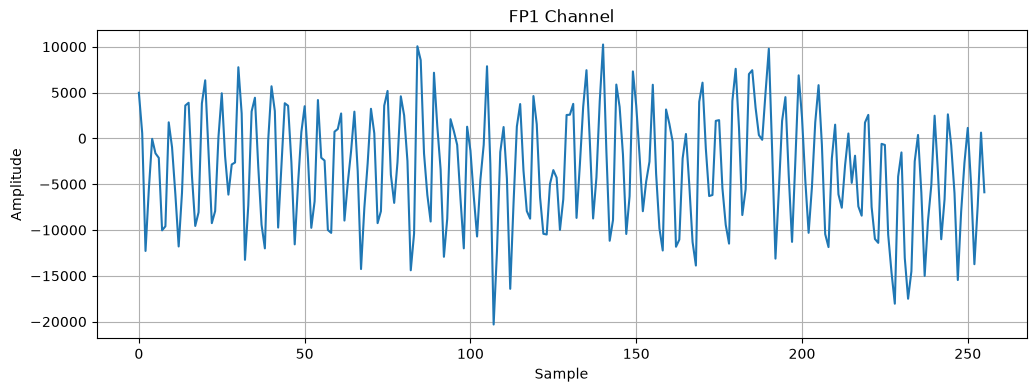

In [21]:
plt.figure(figsize=(12,4))

plt.plot(fp1_signal)

plt.title("FP1 Channel")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

## Summary so far

So far, we have successfully explored and validated the Hugging Face version of the MindBigData2023 MNIST-2B dataset.

### Key Findings

- One sample corresponds to one EEG trial.
- Each trial contains **128 EEG channels**.
- Each channel contains **256 samples**.
- Total EEG values per trial: **32,768**.
- Total columns per sample: **33,559**.
- The dataset includes label information, MNIST image pixels, and session metadata.

These findings establish the actual dataset structure that will be used for preprocessing and model development in subsequent phases.

## 6. Explore Dataset Distribution

Understanding the overall dataset distribution is essential before training machine learning models.

In this section, we will answer the following questions:

- What labels exist?
- How many samples belong to each label?
- How many blank (`-1`) trials are present?
- Is the dataset balanced?
- How are sessions distributed?
- How are recording blocks organized?

Since the dataset is streamed from Hugging Face, we will initially analyze a subset of the dataset.

In [22]:
# Number of samples to analyze
NUM_SAMPLES = 5000

In [23]:
train_iter = iter(ds["train"])

labels = []
sessions = []
blocks = []
block_positions = []

for i, sample in enumerate(train_iter):

    if i >= NUM_SAMPLES:
        break

    labels.append(sample["label"])
    sessions.append(sample["sessionnum"])
    blocks.append(sample["blocknum"])
    block_positions.append(sample["blockpos"])

print(f"Processed {len(labels)} samples.")

Processed 5000 samples.


In [24]:
print(f"Unique labels   : {sorted(set(labels))}")
print(f"Unique sessions : {len(set(sessions))}")
print(f"Unique blocks   : {len(set(blocks))}")

Unique labels   : [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Unique sessions : 13
Unique blocks   : 100


In [25]:
label_counts = pd.Series(labels).value_counts().sort_index()

label_counts

-1    2500
 0     234
 1     277
 2     247
 3     240
 4     280
 5     227
 6     254
 7     275
 8     222
 9     244
Name: count, dtype: int64

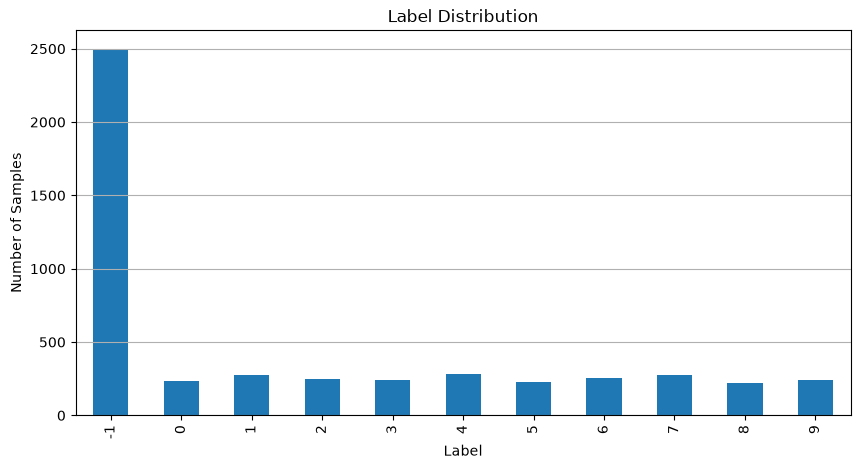

In [26]:
plt.figure(figsize=(10,5))

label_counts.plot(kind="bar")

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Samples")

plt.grid(axis="y")

plt.show()

In [27]:
label_percentages = (
    label_counts / label_counts.sum() * 100
).round(2)

pd.DataFrame({
    "Count": label_counts,
    "Percentage": label_percentages
})

,Count,Percentage
-1,2500,50.00
0,234,4.68
1,277,5.54
2,247,4.94
3,240,4.80
4,280,5.60
5,227,4.54
6,254,5.08
7,275,5.50
8,222,4.44


### Observation

The first 5,000 streamed samples show a highly balanced label distribution.

- Blank (`-1`) trials account for approximately **50%** of the data.
- Digit trials (`0–9`) account for the remaining **50%**.
- Individual digit classes are approximately equally represented.

This balanced distribution supports the planned hierarchical classification strategy:

1. **Stage 1:** Blank vs. Digit
2. **Stage 2:** Digit (0–9)

## 6. Explore Recording Sessions

The dataset provides session-level metadata.

Understanding how trials are distributed across recording sessions is important because it influences how we should split the dataset later to avoid data leakage.

In [28]:
session_counts = pd.Series(sessions).value_counts().sort_index()

session_counts.head(10)

0    1000
1      50
2     618
3     340
4    1000
5      90
6      10
7     510
8     390
9     360
Name: count, dtype: int64

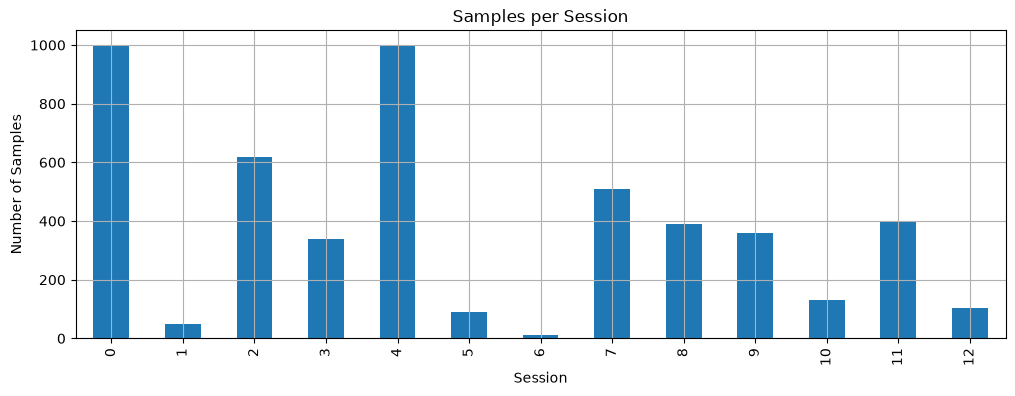

In [33]:
plt.figure(figsize=(12,4))
session_counts.plot(kind="bar")
plt.title("Samples per Session")
plt.xlabel("Session")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.show()

In [30]:
block_counts = pd.Series(blocks).value_counts().sort_index()

block_counts.head(10)

0    130
1    120
2    120
3    120
4    120
5    110
6    110
7    110
8    110
9    100
Name: count, dtype: int64

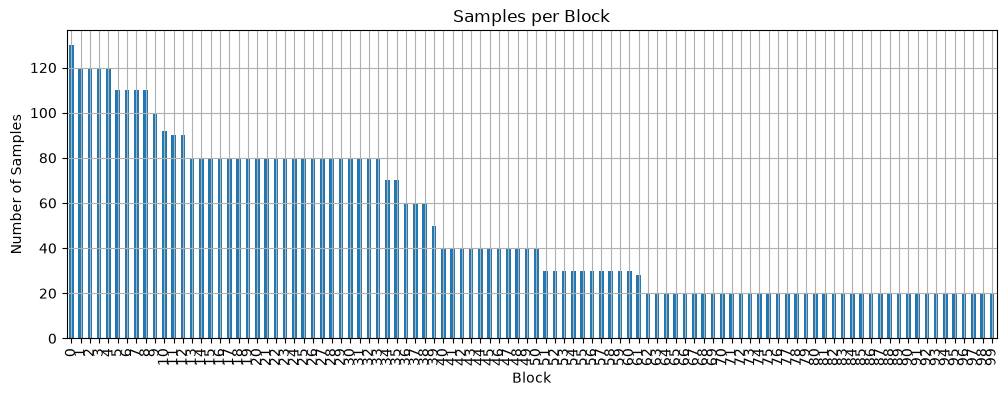

In [34]:
plt.figure(figsize=(12,4))
block_counts.plot(kind="bar")
plt.title("Samples per Block")
plt.xlabel("Block")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.show()

## 7. Inspect Label Ordering

Rather than looking only at label frequencies, we also inspect the order in which labels appear.

This helps us understand whether blank (`-1`) trials alternate with digit trials or whether recordings are grouped in another way.

In [32]:
train_iter = iter(ds["train"])
ordered_labels = []

for i, sample in enumerate(train_iter):
    if i >= 100:
        break
    ordered_labels.append(sample["label"])

ordered_labels

[-1,
 5,
 -1,
 0,
 -1,
 4,
 -1,
 1,
 -1,
 9,
 -1,
 2,
 -1,
 1,
 -1,
 3,
 -1,
 1,
 -1,
 4,
 -1,
 3,
 -1,
 5,
 -1,
 3,
 -1,
 6,
 -1,
 1,
 -1,
 7,
 -1,
 2,
 -1,
 8,
 -1,
 6,
 -1,
 9,
 -1,
 4,
 -1,
 0,
 -1,
 9,
 -1,
 1,
 -1,
 1,
 -1,
 2,
 -1,
 4,
 -1,
 3,
 -1,
 2,
 -1,
 7,
 -1,
 3,
 -1,
 8,
 -1,
 6,
 -1,
 9,
 -1,
 0,
 -1,
 5,
 -1,
 6,
 -1,
 0,
 -1,
 7,
 -1,
 6,
 -1,
 1,
 -1,
 8,
 -1,
 7,
 -1,
 9,
 -1,
 3,
 -1,
 9,
 -1,
 8,
 -1,
 5,
 -1,
 9,
 -1,
 3]

## Findings Summary

From the exploratory analysis, we confirmed:

- The Hugging Face dataset differs from the original paper by containing **256 samples per channel** instead of 500.
- Each trial contains **128 EEG channels**.
- The dataset includes blank (`-1`) trials in addition to digit trials (`0–9`).
- Labels and metadata are available for every trial.
- Session and block metadata will be useful when designing leakage-safe train/validation/test splits.

The dataset is now sufficiently understood to begin preprocessing and preparing machine learning-ready tensors.